# Machine Learning 2 — Assignment #2: Reducción de Dimensionalidad y Clustering con DBSCAN (PCA, Kernel PCA, t-SNE y UMAP)

## Introducción

En este taller se exploran técnicas de **reducción de dimensionalidad** y su impacto sobre tareas de **clustering**. En particular, se aplicarán **PCA**, **Kernel PCA**, **t-SNE** y **UMAP** para proyectar datos de alta dimensión a un espacio de menor dimensión (2D), con el fin de evaluar si estas transformaciones mejoran la **separabilidad visual y estructural** de los grupos.

Posteriormente, se ejecutará el algoritmo **DBSCAN** sobre cada embedding generado para analizar cómo cambia el comportamiento del clustering según la técnica utilizada. Se comparará el **número de clusters detectados**, la **presencia de ruido (outliers)** y la estabilidad de los agrupamientos, discutiendo cuál método preserva mejor la estructura del conjunto de datos y si el espacio reducido ofrece una representación útil para segmentación y toma de decisiones.


In [ ]:
import pandas                   as pd
import numpy                    as np
import umap
import matplotlib.pyplot        as plt
from sklearn.preprocessing      import StandardScaler
from sklearn.preprocessing      import StandardScaler
from sklearn.decomposition      import PCA
from sklearn.decomposition      import KernelPCA
from sklearn.manifold           import TSNE

df_fifa = pd.read_csv("df_FIFA_cleaned_processed.csv")                      # 1) Cargar datasets
df_air_raw = pd.read_csv("df_EastWestAirlines_processed.csv")
df_fifa_num = df_fifa.select_dtypes(include=[np.number]).copy()
df_air_clean = df_air_raw.drop(columns=["ID#", "Award?"], errors="ignore")  # Airlines (remover columnas no útiles si existen, luego filtrar numéricas)
df_air_num = df_air_clean.select_dtypes(include=[np.number]).copy()
print("FIFA num shape:", df_fifa_num.shape)
print("Airlines num shape:", df_air_num.shape)
scaler_fifa = StandardScaler()
X_fifa = scaler_fifa.fit_transform(df_fifa_num)                             #3) Escalado (StandardScaler)
scaler_air = StandardScaler()
X_air = scaler_air.fit_transform(df_air_num)
display(df_fifa_num.head())
display(df_air_num.head())

FIFA num shape: (18852, 10)
Airlines num shape: (3999, 10)


,Finishing,Short Passing,Standing Tackle,Sprint Speed,Strength,Dribbling,Crossing,Interceptions,Vision,GK Reflexes
0,1.515166,2.835984,-0.526155,0.869715,0.180269,2.419793,1.440356,-0.334052,2.400562,-0.623331
1,1.515166,1.796169,-0.602847,1.741445,0.753743,1.778358,1.389326,-0.614233,1.562314,0.000000
2,-1.124239,-1.106170,-1.091913,-0.397606,0.753743,-1.663020,-1.337373,-0.866243,0.548278,1.661744
3,1.075732,3.216192,0.270939,0.583747,0.492882,1.778358,1.912162,0.336511,2.334274,0.268810
4,1.243843,2.355368,-0.653585,1.573577,-0.865504,2.336773,1.440356,-0.436236,2.072082,0.000000


,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,-0.257279,0.0,0.000000,0.0,0.0,-0.888778,-1.022274,0.000000,0.000000,0.763229
1,-0.472329,0.0,0.000000,0.0,0.0,-0.855940,-0.861082,0.000000,0.000000,0.755377
2,-0.025703,0.0,0.000000,0.0,0.0,-0.184356,-0.616717,0.000000,0.000000,0.771561
3,-0.614238,0.0,0.000000,0.0,0.0,-0.707787,-1.022274,0.000000,0.000000,0.751447
4,0.546834,0.0,1.149512,0.0,0.0,0.787737,0.660697,1.072093,1.344437,0.747269


## 1) Escalar (solo numéricas) y definir un helper para plots

In [ ]:
scaler = StandardScaler()
X_fifa = scaler.fit_transform(df_fifa_num)
X_air  = scaler.fit_transform(df_air_num)

print("X_fifa:", X_fifa.shape, "| X_air:", X_air.shape)

def plot_embedding(Z, title):
    plt.figure(figsize=(7,5))
    plt.scatter(Z[:,0], Z[:,1], s=10)
    plt.title(title)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(alpha=0.2)
    plt.show()

X_fifa: (18852, 10) | X_air: (3999, 10)


## 2) PCA (2D) + varianza explicada

FIFA 25 Players | PCA(2D) explained variance = 0.710


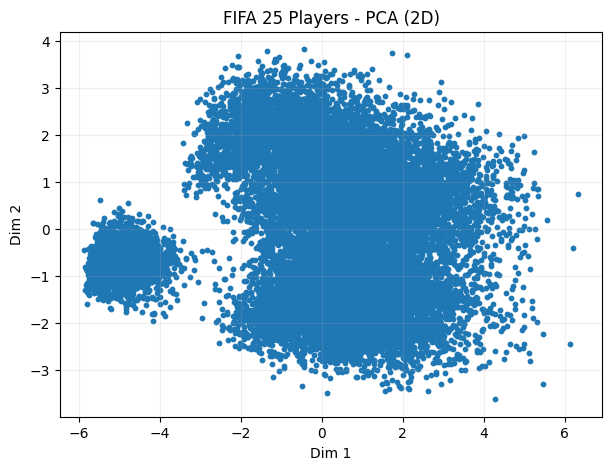

East West Airlines | PCA(2D) explained variance = 0.514


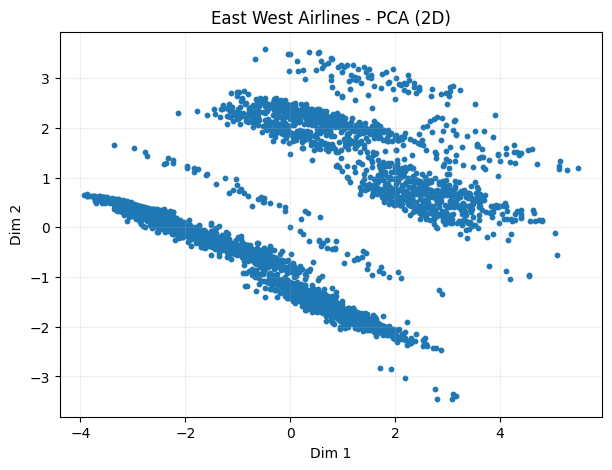

In [ ]:
def run_pca(X, dataset_name):
    pca = PCA(n_components=2, random_state=42)
    Z = pca.fit_transform(X)
    evr = pca.explained_variance_ratio_.sum()
    print(f"{dataset_name} | PCA(2D) explained variance = {evr:.3f}")
    plot_embedding(Z, f"{dataset_name} - PCA (2D)")
    return Z, pca

Z_pca_fifa, pca_fifa = run_pca(X_fifa, "FIFA 25 Players")
Z_pca_air,  pca_air  = run_pca(X_air,  "East West Airlines")

## 3) Kernel PCA (2D)

Kernel PCA no tiene “explained variance” como PCA, así que lo evaluamos visualmente (y luego con DBSCAN en el Punto 2).

FIFA 25 Players | KernelPCA(2D) kernel=rbf, gamma=0.1000


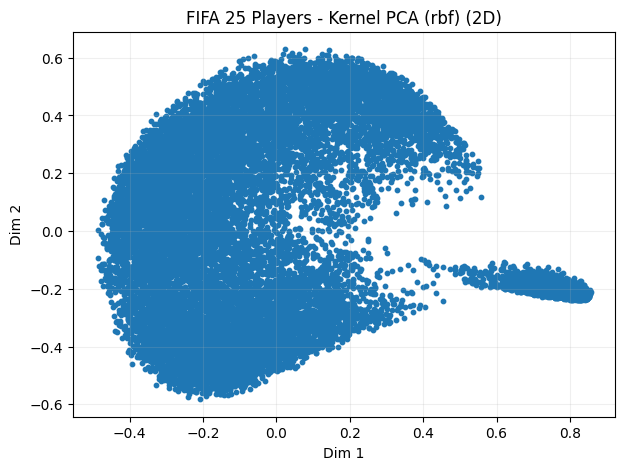

East West Airlines | KernelPCA(2D) kernel=rbf, gamma=0.1000


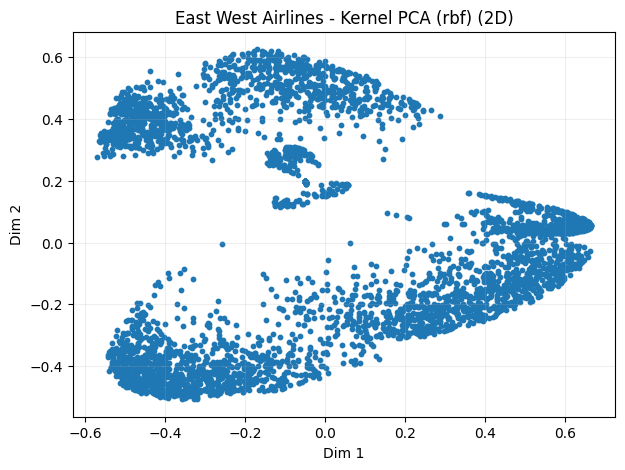

In [ ]:
def run_kpca(X, dataset_name, kernel="rbf"):
    # gamma base: 1 / num_features (buen punto de partida)
    gamma = 1 / X.shape[1]
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=gamma)
    Z = kpca.fit_transform(X)
    print(f"{dataset_name} | KernelPCA(2D) kernel={kernel}, gamma={gamma:.4f}")
    plot_embedding(Z, f"{dataset_name} - Kernel PCA ({kernel}) (2D)")
    return Z, kpca

Z_kpca_fifa, kpca_fifa = run_kpca(X_fifa, "FIFA 25 Players", kernel="rbf")
Z_kpca_air,  kpca_air  = run_kpca(X_air,  "East West Airlines", kernel="rbf")

## 4) t-SNE (2D)

FIFA 25 Players | t-SNE(2D) perplexity=30


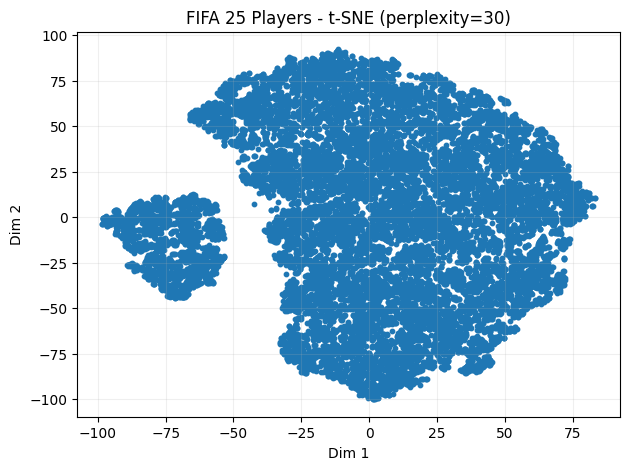

East West Airlines | t-SNE(2D) perplexity=30


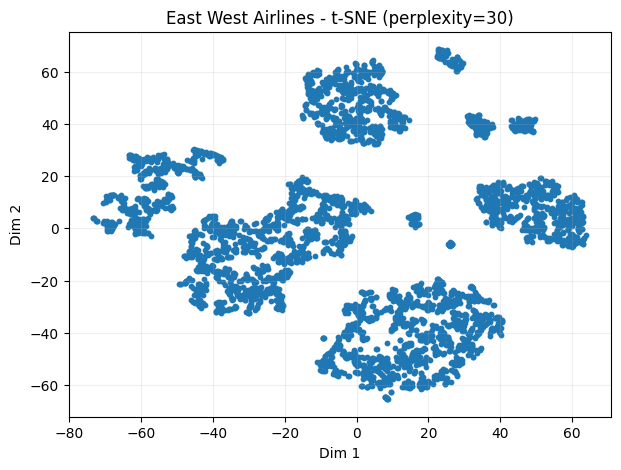

In [5]:
def run_tsne(X, dataset_name, perplexity=30):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=42
    )
    Z = tsne.fit_transform(X)
    print(f"{dataset_name} | t-SNE(2D) perplexity={perplexity}")
    plot_embedding(Z, f"{dataset_name} - t-SNE (perplexity={perplexity})")
    return Z, tsne

Z_tsne_fifa, tsne_fifa = run_tsne(X_fifa, "FIFA 25 Players", perplexity=30)
Z_tsne_air,  tsne_air  = run_tsne(X_air,  "East West Airlines", perplexity=30)

In [ ]:
um = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Z_umap_fifa = um.fit_transform(X_fifa)
Z_umap_air  = um.fit_transform(X_air)

print(Z_umap_fifa.shape, Z_umap_air.shape)

c:\Users\isaac\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(18852, 2) (3999, 2)


## Interpretación de los embeddings (PCA, Kernel PCA, t-SNE y UMAP)

### Tamaño de los datos
- **FIFA 25 Players:** \(X\_\text{fifa}\) tiene forma **(18852, 10)** (18.852 jugadores, 10 variables numéricas).
- **East West Airlines:** \(X\_\text{air}\) tiene forma **(3999, 10)** (3.999 clientes, 10 variables numéricas).
- Todos los métodos redujeron a **2D**: **(18852, 2)** y **(3999, 2)**, respectivamente.

> Nota sobre UMAP: el *warning* indica que al fijar `random_state` se fuerza `n_jobs=1` para reproducibilidad (no paraleliza). No afecta la validez del embedding; solo el rendimiento.

---

### 1) PCA (2D)
- **FIFA (PCA):** se observa una **masa principal muy densa** y un **grupo claramente separado** hacia la izquierda. Esto sugiere que existe al menos un segmento distinto (posibles outliers/perfiles extremos), pero dentro del grupo principal hay **alto solapamiento**, por lo que la separabilidad no es totalmente clara en 2D.
- **Airlines (PCA):** se aprecian **estructuras más diferenciadas** (bandas/zonas separables) comparado con FIFA. Esto indica que una parte importante de la estructura puede capturarse incluso con una proyección lineal.

**Interpretación general:** PCA preserva estructura global basada en varianza; si los clusters no son lineales o se solapan en el espacio original, en 2D puede verse “mezclado”.

---

### 2) Kernel PCA (RBF, 2D)
- **FIFA (Kernel PCA):** el embedding toma forma de **una nube continua** con un “brazo/cola” hacia una región específica. Esto puede indicar una **estructura no lineal** y/o presencia de observaciones extremas; sin embargo, sigue predominando una **transición gradual** más que clusters compactos bien separados.
- **Airlines (Kernel PCA):** aparecen **regiones mejor separadas** (formas curvas/arcos), lo que sugiere que hay patrones no lineales en el comportamiento de clientes que Kernel PCA logra resaltar mejor que PCA.

**Interpretación general:** Kernel PCA puede “desenrollar” relaciones no lineales y mejorar separabilidad, especialmente cuando PCA no logra separar.

---

### 3) t-SNE (2D)
- **FIFA (t-SNE):** se mantiene un **grupo grande dominante** y se observa al menos un **“isla” separada**, además de subestructura interna. Esto sugiere que hay vecindades locales (microsegmentos) pero no necesariamente fronteras limpias entre grupos grandes.
- **Airlines (t-SNE):** se observan **múltiples islas claramente separadas**, lo que indica una separabilidad local muy marcada; esto suele ser favorable para algoritmos basados en densidad como DBSCAN.

**Interpretación general:** t-SNE está optimizado para preservar vecindades locales (visualización). Puede “exagerar” separaciones globales, por lo que es ideal para inspección visual y para probar DBSCAN, pero no debe interpretarse como distancias globales exactas.

---

### 4) UMAP (2D)
- Se generaron embeddings 2D exitosamente para ambos datasets (**(18852,2)** y **(3999,2)**).
- UMAP suele preservar estructura local y parte de la global, y frecuentemente produce espacios 2D muy adecuados para DBSCAN (zonas densas + separación natural).

**Interpretación general:** UMAP es un candidato fuerte para evaluar separabilidad con DBSCAN, especialmente si t-SNE mostró islas bien definidas.

---

## Conclusión del Punto 1 (Reducción de dimensionalidad)
- En **FIFA**, los métodos muestran una **estructura dominante** con posibles subgrupos y al menos un segmento separado, pero la separabilidad de múltiples clusters grandes no es totalmente evidente solo con el embedding (especialmente en PCA). Aquí es clave evaluar DBSCAN para ver si aparecen clusters robustos o si predomina una gran región con ruido.
- En **Airlines**, tanto PCA como (más claramente) Kernel PCA y t-SNE sugieren **mayor separabilidad**. Por lo tanto, se espera que DBSCAN detecte **más de un cluster** y que la representación reducida sea más útil para segmentación.

En el siguiente punto (DBSCAN), se evaluará formalmente esta separabilidad comparando para cada embedding: **número de clusters detectados**, **cantidad de ruido/outliers**, y (si aplica) métricas internas como Silhouette sobre puntos no-ruido.